# Instancia de evaluación: Participación en Foro Obligatorio

Utilizaremos un conjunto de datos que nos interese trabajar y mediante la implementación de los algoritmos Árbol de Decisión y K-NN, evaluaremos y compararemos la precisión de los clasificadores generados.

Esta tarea nos permitirá no solo poner a prueba nuestras habilidades en la construcción de modelos, sino también comprender cómo diferentes enfoques de aprendizaje automático pueden tener un impacto significativo en los resultados.

Al finalizar la actividad, analizaremos detenidamente los resultados obtenidos, lo que nos proporcionará una visión más profunda de las fortalezas y debilidades de cada algoritmo en el contexto de la clasificación de datos, y nos ayudará a tomar decisiones informadas sobre su implementación en problemas del mundo real.

En el foro de intercambio deberás compartir los datasets con los que te interese trabajar y cuál sería la tarea a realizar mediante los modelos de aprendizaje automático



In [58]:
# 1 - Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

# Datos de Kaggle de precios de horas de uso de redes sociales
dat_csv = pd.read_csv('games.csv', encoding = "ISO-8859-1")

# Limitando la cantidad de registros a los primeros 50
df = dat_csv[["rated", "turns", "winner", "opening_eco", "white_rating", "black_rating"]]
df_limpio = df.head(100)
df_limpio.head(10)



,rated,turns,winner,opening_eco,white_rating,black_rating
0,False,13,white,D10,1500,1191
1,True,16,black,B00,1322,1261
2,True,61,white,C20,1496,1500
3,True,61,white,D02,1439,1454
4,True,95,white,C41,1523,1469
5,False,5,draw,B27,1250,1002
6,True,33,white,D00,1520,1423
7,False,9,black,B00,1413,2108
8,True,66,black,C50,1439,1392
9,True,119,white,B01,1381,1209


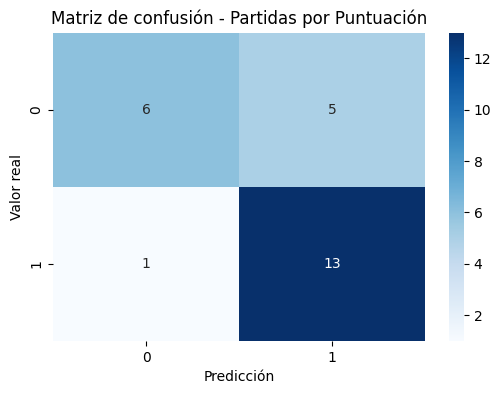

              precision    recall  f1-score   support

       False       0.86      0.55      0.67        11
        True       0.72      0.93      0.81        14

    accuracy                           0.76        25
   macro avg       0.79      0.74      0.74        25
weighted avg       0.78      0.76      0.75        25



In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir variables categóricas en variables dummies (0/1)
usu_encoded = pd.get_dummies(df_limpio, drop_first=True)


# Variable objetivo "Partida Por Puntuacion"
X_rated = usu_encoded.drop("rated", axis=1)
y_rated = usu_encoded["rated"]

# 25% de prueba y 75% de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X_rated, y_rated, test_size=0.25, random_state=42)

# Creamos el modelo de regresión logística binaria
log_reg_binaria = LogisticRegression(max_iter=1000)
log_reg_binaria.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred_usu = log_reg_binaria.predict(X_test)

# Matriz de confusión para comparar valores reales vs predicciones
cm_usu = confusion_matrix(y_test, y_pred_usu)
plt.figure(figsize=(6,4))
sns.heatmap(cm_usu, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Matriz de confusión - Partidas por Puntuación")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.show()
print(classification_report(y_test, y_pred_usu))

En este primer modelo podemos observar que en 100 registros el modelo de predicción consiguió acertar casi un 80% de los casos

Métricas KNN:
              precision    recall  f1-score   support

       False       0.67      0.15      0.25        13
        True       0.59      0.94      0.73        17

    accuracy                           0.60        30
   macro avg       0.63      0.55      0.49        30
weighted avg       0.62      0.60      0.52        30

Metricas Arbol de desición
              precision    recall  f1-score   support

       False       0.67      0.77      0.71        13
        True       0.80      0.71      0.75        17

    accuracy                           0.73        30
   macro avg       0.73      0.74      0.73        30
weighted avg       0.74      0.73      0.73        30

Accuracy KNN: 0.6
Accuracy Árbol: 0.7333333333333333


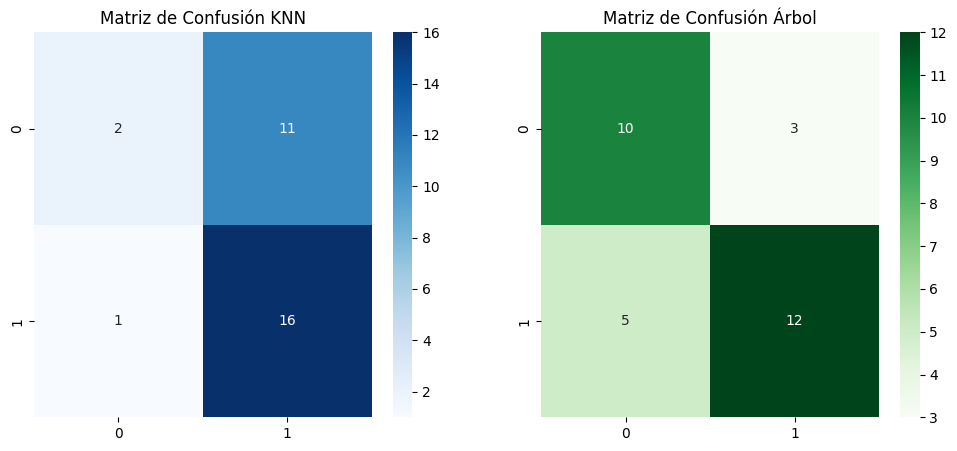

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

# Entrenamiento y Prueba

X_train, X_test, y_train, y_test = train_test_split(X_rated, y_rated, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn))

# Arbol de Decisión

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Metricas Arbol de desición")
print(classification_report(y_test, y_pred_tree))

# Evaluación de métricas

print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión KNN")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol")
plt.show()

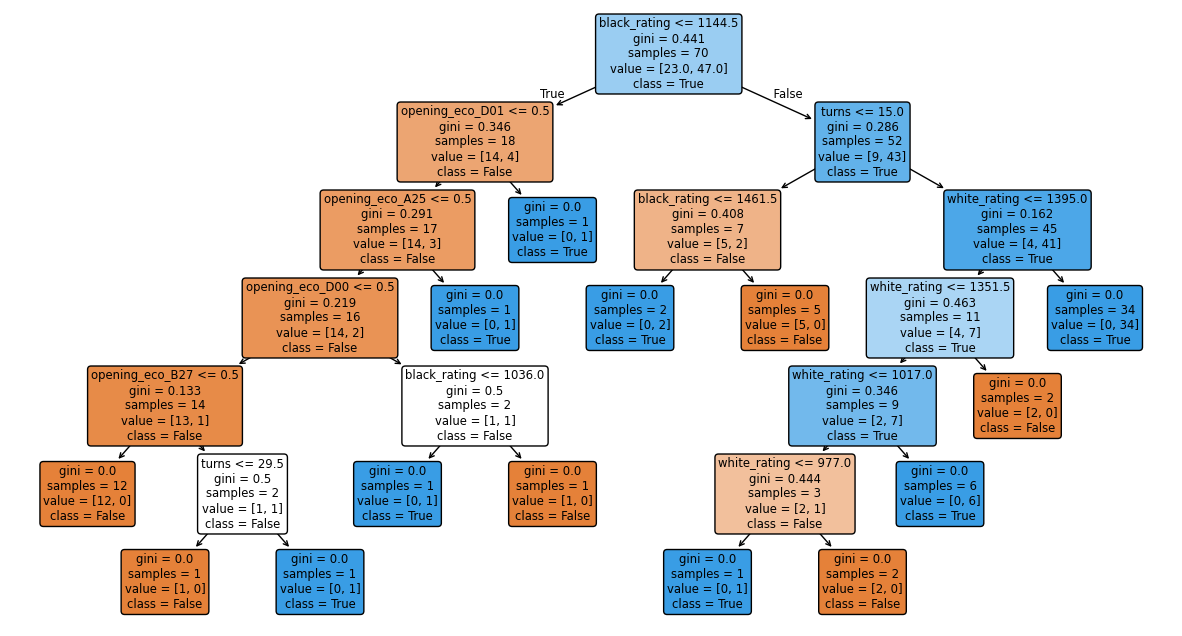

In [69]:
plt.figure(figsize=(15,8))
plot_tree(tree, feature_names=X_rated.columns, class_names=[str(c) for c in tree.classes_], filled=True, rounded=True)
plt.show()

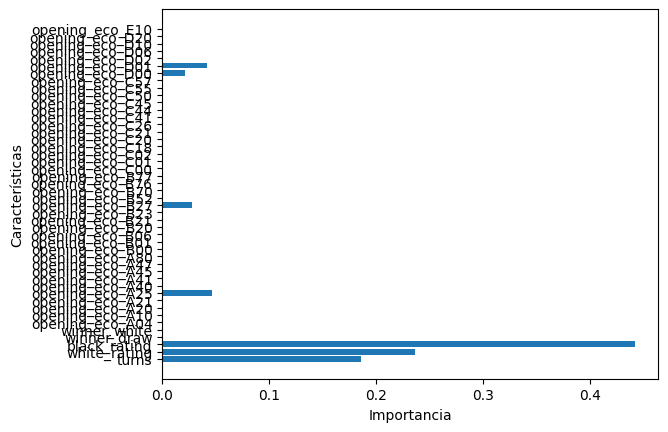

In [73]:
caracteristica = len(X_rated.columns)

plt.barh(range(caracteristica), tree.feature_importances_)
plt.yticks(np.arange(caracteristica), X_rated.columns)
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.show()